In [3]:
from transformers import pipeline

# Initialize the speech-to-text pipeline
speech_to_text = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base",
    return_timestamps=True,
)

Device set to use cpu


In [4]:
# Load your audio file
audio_path = "cabrel.wav"

# Perform speech-to-text
transcription = speech_to_text(audio_path)

# Print the transcription
print(transcription)


/home/lgiron/lab_perso/python_course/.venv/lib/python3.12/site-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.


{'text': "... Il arrive à le voir, elle le veut Et ses yeux font le reste Elle s'arrange pour mettre du feu Dans chacun de ses gestes Après cette une histoire classique Quelque soit la fumée, Quelque soit la musique, Elle relève ses cheveux, Elle espère qu'il devine Dans ses yeux de figurine, Il s'installe, Il regarde partout, Il prépare ses phrases Comme elle s'est avancée un peu D'un coup, leur regard se croise Après, c'est une histoire normale Le verre qu'elle accepte Les sourires qu'il est à l'un Dans sa prochaine, un peu Il voit les ombres fines Dans ses yeux de figurine Voilà peine que je précise D'où il vienne Et ceux qu'il se disent C'est une histoire d'enfants, une histoire ordinaire On est tout simplement, simplement Un samedi soir sur la terre Un samedi soir sur la terre Il se parle, il se froide, il s'avent bien qu'il va falloir qu'il sort Ils sont obligés de se toucher tellement la musique est forte Après c'est juste une aventure Qui commence sur le siège arrière du neuvat

In [ ]:
# Save the transcription to a file
with open("transcription.txt", "w") as f:
    text = transcription["text"]
    f.write(text)
    

In [ ]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

def preprocess_text(text):
    # Supprimer la ponctuation
    text = re.sub(r"[^\w\s]", "", text)
    # Convertir en minuscules
    text = text.lower()
    # Supprimer les mots de liaison
    stop_words = set(stopwords.words("french"))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


def generate_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
        text
    )
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

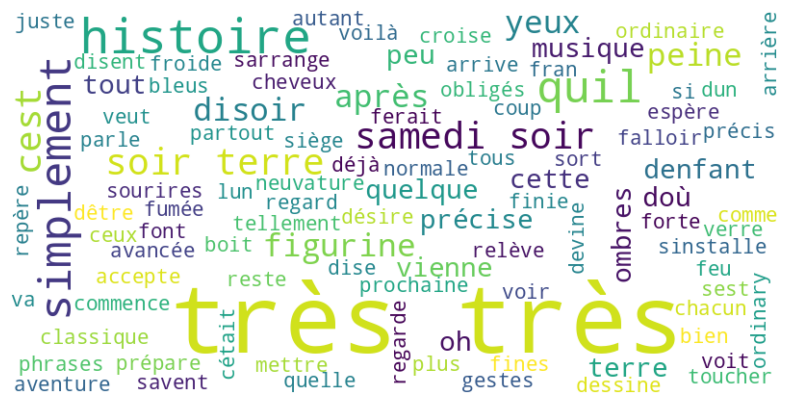

In [8]:
processed_text = preprocess_text(text)
generate_wordcloud(processed_text)